# Computer Book A: The Binomial Distribution

These series of codes, illustrate using python, the various exercises from the OU course M248 Analysing Data. The exercises were originally written to be carried out using Minitab statistical software but those exercises have been re-done in Python below.

### Reference formulas

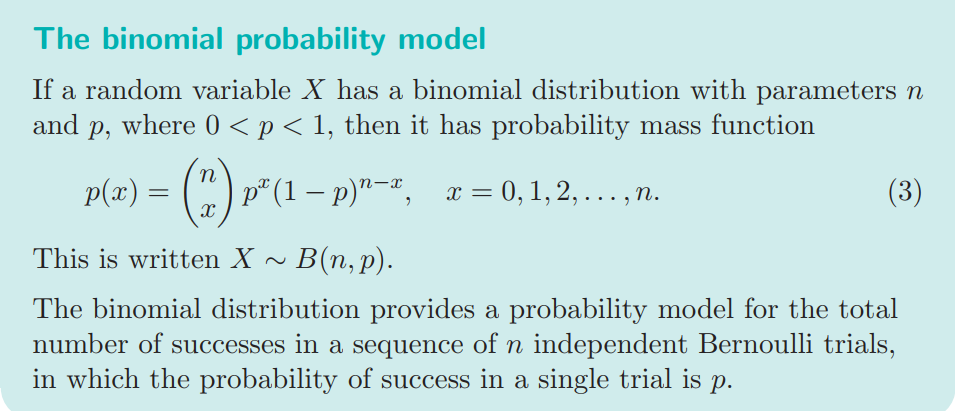

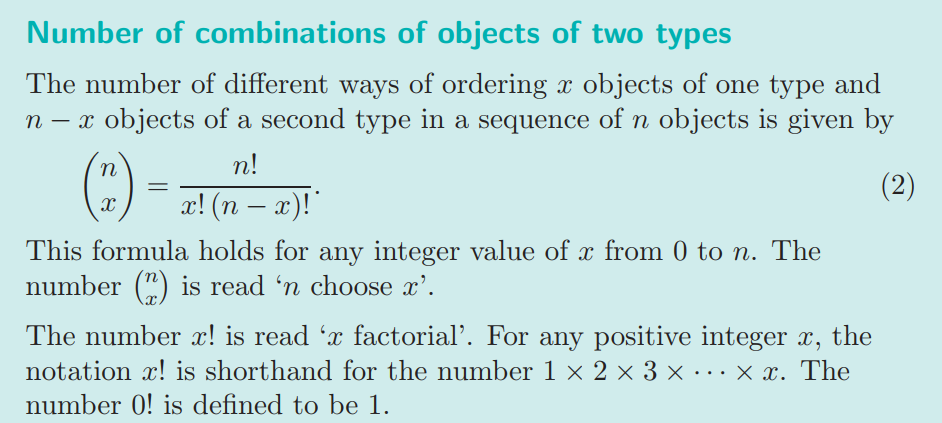

## Computer activity 27: Multiple choice examination scores

An examination consists of twenty multiple choice questions. For each question, the correct answer is one of five options. The random variable T, which denotes the number of correct answers obtained by a student who guesses answers at random, has a binomial distribution $T ∼ B(20, 0.2)$.

Find the probability that the student scores exactly 10 and so just passes the examination i.e. $P(T = 10)$, where $T ∼ B(20, 0.2)$

Note: The probability of answering one correct question is 20%

In [3]:
from math import comb
n = 20
x = 10
p = 0.2

# Work out the binomial coefficient i.e the number of possible combinations of n and x i.e. the number of ways of obtaining 
# 10 correct answers out of 20

binomial_coefficient = comb(n, x)
print(f"Bionmial Coefficient: {binomial_coefficient}")

# Determine the probability according to the Binomial distribution
probability = binomial_coefficient * (p**x) * ((1-p)**(n-x))
print(f"Probability: {round(probability,7)}")

Bionmial Coefficient: 184756
Probability: 0.0020314


Therefore, the probability that a student who guesses at random obtains exactly 10 correct answers is around 0.002 or 0.2%

## Computer activity 28: Fail the multiple choice examination?

In Computer activity 27, T , the number of correct answers obtained by a student taking a multiple choice examination who guesses answers at random, has a binomial distribution T ∼ B(20, 0.2). To pass the test, the student must get at least 10 out of the 20 questions correct. In this activity, you will obtain the probability that the student fails the examination.

If the student needs to answer at least 10 questions correctly to pass the examination, then the probability that the student fails is:

$P (T < 10) = P (T ≤ 9) = F (9)$,

where F (t) = P (T ≤ t) is the c.d.f. of random variable T. 



In [5]:
from scipy.stats import binom

# Define the parameters
n = 20    # Number of trials
p = 0.2   # Probability of success
x = 9     # The value we want the CDF up to (T <= 9)

# Calculate the CDF using the cdf function
result = binom.cdf(x, n, p)

print(f"P(T <= 9) = {result}")

P(T <= 9) = 0.9974051725993259


Note that there is no convinient mathematical formula to calculate the CDF (The probability that X, a given random variable, takes a value less than or equal to x:) of a binomial random variable hence for each trial the probability as to be caculuated up to the 'limit' value and then added together as illustrated below:

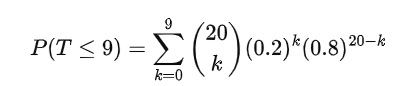

Hence, the probability that a student who guesses answers at random fails is 0.99 or 99%

## Computer activity 29: Retake or resit?

Consider once again the multiple choice examination of Computer activity 27.

(a) Suppose that students have to retake the module the following year if they answer fewer than four questions out of twenty correctly. What is the probability that a student who guesses answers at random has to retake the module?

(b) Students who fail the examination (that is, score less than 10) are allowed to resit the examination without retaking the whole module if they answer at least four out of the twenty questions correctly. What is the probability that a student who guesses answers at random fails but is allowed to resit the examination?

Question (a) just needs to be restated as follows and coded in Python as before using the binom library:

$P (T < 4) = P (T ≤ 3) = F (3)$

In [1]:
from scipy.stats import binom

# Define the parameters
n = 20    # Number of trials
p = 0.2   # Probability of success
x = 3     # The value we want the CDF up to (T <= 9)

# Calculate the CDF using the cdf function
result = binom.cdf(x, n, p)

print(f"P(T <= 4) = {round(result,2)}")

P(T <= 4) = 0.41


Question (b) is essentially asking what is the probability that a student gets more than 4 questions right but unfortunately does not get more than 10 questions right and thus goes on to fail.

Again this needs to be restated in the binomial distribution language as:<br>

$P (4 \leq T < 10) = P (4 \leq T \leq9) = P(T \le 9) - P(T \le 3)$

We need to find the c.d.f (cummulative distribution function) at $P(T \le 9)$ and $P(T \le 3)$ and substract to find the total probability in between these two c.d.fs.

In [6]:
from scipy.stats import binom

n = 20 # Number of trials
p = 0.2 # Probability of success

# Calculate P(T <= 9)
prob_9 = binom.cdf(9, n, p)

# Calculate P(T <= 3)
prob_3 = binom.cdf(3, n, p)

# Result
result = prob_9 - prob_3

print(f"Prob at 9: {prob_9}")
print(f"Prob at 3: {prob_3}")
print(f"Final prob: {result}")

Prob at 9: 0.9974051725993259
Prob at 3: 0.41144886195656893
Final prob: 0.585956310642757


### A note on the c.d.f and continous random variables

It is important to note the subtle but important difference of the intervals of cdfs. For a continuos random variable the probabilities of $P(X<x)$ and $P(X\leq x)$ will both have the same area under the graph because the probability that the random variable X takes exactly the value of x is zero. However, if the random variable is distcrete then $P(X<x)$ and $P(X\leq x)$ are not the same e.g. $P(X<4)$ and $P(X\leq 3)$ are clearly not the same in the discrete values.

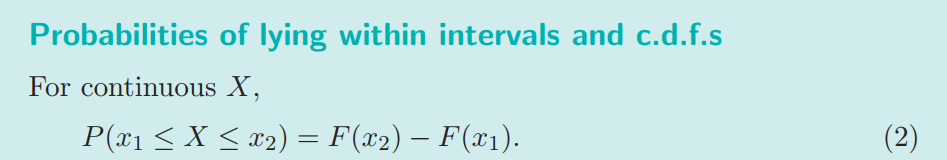

*A random variable is a set of possible values from a randon experiment e.g. tossing a coin can take on 2 values: head or tails*


## Computer activity 30: Obtaining a table of results

In this activity, you will obtain a table containing values of the p.m.f. and the c.d.f. for the binomial distribution B(20, 0.2).

In [1]:
from scipy.stats import binom
import pandas as pd

n = 20
p = 0.2

data = []
for t in range(n + 1):
    pmf = binom.pmf(t, n, p)
    cdf = binom.cdf(t, n, p)
    data.append([t, pmf, cdf])

df = pd.DataFrame(data, columns=['t', 'P(T=t)', 'P(T<=t)'])
print(df.to_string(index=False))

 t       P(T=t)  P(T<=t)
 0 1.152922e-02 0.011529
 1 5.764608e-02 0.069175
 2 1.369094e-01 0.206085
 3 2.053641e-01 0.411449
 4 2.181994e-01 0.629648
 5 1.745595e-01 0.804208
 6 1.090997e-01 0.913307
 7 5.454985e-02 0.967857
 8 2.216088e-02 0.990018
 9 7.386959e-03 0.997405
10 2.031414e-03 0.999437
11 4.616849e-04 0.999898
12 8.656592e-05 0.999985
13 1.331783e-05 0.999998
14 1.664729e-06 1.000000
15 1.664729e-07 1.000000
16 1.300570e-08 1.000000
17 7.650410e-10 1.000000
18 3.187671e-11 1.000000
19 8.388608e-13 1.000000
20 1.048576e-14 1.000000


Plotting the PMF and the CDF alongside the random variable t shows the difference in interpreting the p.m.f and the c.d.f:
1. The p.m.f (Probability Mass Function) is the probability of exactly t successes e.g. the probability of getting exactly 10 questions out of 20 right i.e. $t=10$
2. The c.d.f (Cummulative Distribution Function) is the probability of at most t successes e.g. the probability of getting less than 10 questions out of 20 right i.e. $t\le 9$

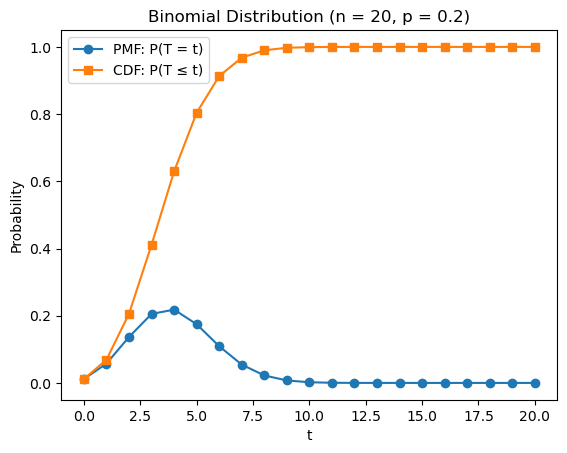

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot PMF and CDF together
plt.figure()
plt.plot(df['t'], df['P(T=t)'], marker='o', label='PMF: P(T = t)')
plt.plot(df['t'], df['P(T<=t)'], marker='s', label='CDF: P(T ≤ t)')
plt.xlabel('t')
plt.ylabel('Probability')
plt.title('Binomial Distribution (n = 20, p = 0.2)')
plt.legend()
plt.show()

## Computer activity 31: More multiple choice tests

(a) A test consists of ten multiple choice questions, each of which has eight options. A student must answer at least five of the questions correctly to pass the test. Find the probability that a student who guesses answers at random answers exactly five questions correctly, and so just passes the test. What is the probability that such a student fails the test?

(b) In another test, there are thirty questions, each of which has four options. To pass the test, a student must answer at least half of them correctly. Find the probability that a student who guesses answers at random passes the test (that is, answers at least fifteen of the questions correctly).

For question (a) we are being asked to find the probability of a student passing a different test. There are 10 multiple choice questions each with 8 possible options. The probability of the student guessing answers at random is exactly 1 in 8 so we know that the probability p for each bernoulli trial (a series of bernoulli trials has a binomial distribution with parameters p (probability) and n (number of trials)) has p = 1/8 and n = 10.

We frame the problem in terms of the binomial distribution:

$P(T = 5)$, where $T ∼ B(10, 1/8)$

i.e. the probability that the student just passes.

The python code is below:

In [9]:
from math import comb
n = 10
x = 5
p = 0.125

# Work out the binomial coefficient i.e the number of possible combinations of n and x i.e. the number of ways of obtaining 
# 10 correct answers out of 20

binomial_coefficient = comb(n, x)
print(f"Bionmial Coefficient: {binomial_coefficient}")

# Determine the probability according to the Binomial distribution
probability = binomial_coefficient * (p**x) * ((1-p)**(n-x))
print(round(probability,7))

Bionmial Coefficient: 252
0.0039445


The probability that a student who guesses answers at random answers five questions correctly and so just passes is therefore: 0.39%

In order to determine the probability that a student who guesses just fails the test if they get less five correct questions (i.e. correct answers being equal to or less than four) we need to reframe the binomial distribution:

$P(T \leq 4)$, where $T ∼ B(10, 1/8)$

The python code is below:

In [7]:
from scipy.stats import binom

# Define the parameters
n = 10    # Number of trials
p = 0.125   # Probability of success
x = 4     # The value we want the CDF up to (T <= 4)

# Calculate the CDF using the cdf function
result = binom.cdf(x, n, p)

print(f"P(T <= 4) = {round(result,7)}")

P(T <= 4) = 0.9955455


The probability that a student who guesses answers at random answers upto or less than four questions is therefore: 99.55%

For question (b) we are being asked to find the probability that a student on another test who gusses the correct answers passes the test by getting at least 15 out of the 30 questions correct. Each question has four options so the probability per question is 1/4 or 0.25. There are 30 trials i.e. 30 questions each with the same probability of getting the correct answer so well suited to be modelled by the binomial distribution.

The question can be reframed according to the binomial distribution as follows:

$P(T \ge 15) = 1 - P(T \leq 14)$, where $T ∼ B(30, 1/4)$

In [8]:
from scipy.stats import binom

# Define the parameters
n = 30    # Number of trials
p = 0.25   # Probability of success
x = 14     # The value we want the CDF up to (T <= 14)

# Calculate the CDF using the cdf function
result = 1 - binom.cdf(x, n, p)

print(f"P(T <= 14) = {round(result,7)}")

P(T <= 14) = 0.0027495


The probability that a student who guesses answers at random answers at least 15 or more questions correctly is therefore: 0.275%